# Compare ROC curves

Load one or more `*.json` files saved by **`AnalyzeDDIM2DDIM_Outputs.ipynb`** and
overlay them on a single ROC plot.

**Steps**
1. Set `ROC_DIR` (or list explicit `ROC_FILES`).
2. Optionally filter by label / score mode / T.
3. Run all cells.


In [355]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

# ── Configure ────────────────────────────────────────────────────────────────
# Directory that contains the saved ROC JSON files (written by AnalyzeDDIM2DDIM_Outputs).
ROC_DIR = Path("roc_curves")

# Optional: list specific files instead of scanning ROC_DIR.  Leave empty to scan.
ROC_FILES: list[str] = []

# Optional filters (set to None to accept any value).
FILTER_SCORE: str | None = None # e.g. "rms"
FILTER_T: int | None = None        # e.g. 200

# Plot style
SHOW_DIAGONAL = True   # dashed random-classifier line
SHOW_GRID     = True
FIG_SIZE      = (7, 6)

# Smoothing: Gaussian sigma applied to TPR values along the curve.
# Set to 0 to disable smoothing.
SMOOTH_SIGMA  = 1

plt.rcParams["figure.dpi"] = 110

stylefile = "presentation.mplstyle"
plt.style.use(stylefile)


In [368]:
DEFECT_TYPE = "charge_tail"

In [369]:
labels = ["Anisotropic, DDIM to DDIM", "Anisotropic, Random to DDIM", "Anisotropic, Random to DDPM", "Cosine, DDIM to DDIM", "Linear, DDIM to DDIM", "Ramp, DDIM to DDIM"]

In [370]:
# ── Collect ROC JSON files ────────────────────────────────────────────────────
if ROC_FILES:
    candidate_paths = [Path(p) for p in ROC_FILES]
else:
    candidate_paths = sorted(ROC_DIR.glob("*.json"))

records: list[dict] = []
for path in candidate_paths:
    if DEFECT_TYPE and DEFECT_TYPE not in path.stem:
        continue
    with path.open() as fh:
        rec = json.load(fh)
    if FILTER_SCORE is not None and rec.get("score_mode") != FILTER_SCORE:
        continue
    if FILTER_T is not None and rec.get("T") != FILTER_T:
        continue
    records.append(rec)
    print(f"  {path.name}  label={rec.get('label', '?')}  T={rec.get('T', '?')}  score={rec.get('score_mode', '?')}  AUC={rec.get('auc', float('nan')):.4f}")

print(f"\nLoaded {len(records)} ROC curve(s).")


  ICARUS_plane1_charge_tail-anisotropic_T200_rms_ddim2ddim.json  label=ICARUS_plane1_charge_tail-anisotropic  T=200  score=rms  AUC=0.9840
  ICARUS_plane1_charge_tail-anisotropic_T200_rms_rand2ddim.json  label=ICARUS_plane1_charge_tail-anisotropic  T=200  score=rms  AUC=0.5556
  ICARUS_plane1_charge_tail-anisotropic_T200_rms_rand2ddpm.json  label=ICARUS_plane1_charge_tail-anisotropic  T=200  score=rms  AUC=0.5639
  ICARUS_plane1_charge_tail-cosine_T200_rms_ddim2ddim.json  label=ICARUS_plane1_charge_tail-cosine  T=200  score=rms  AUC=0.9533
  ICARUS_plane1_charge_tail-linear_T200_rms_ddim2ddim.json  label=ICARUS_plane1_charge_tail  T=200  score=rms  AUC=0.9461
  ICARUS_plane1_charge_tail-ramp_T200_rms_ddim2ddim.json  label=ICARUS_plane1_charge_tail-ramp  T=200  score=rms  AUC=0.9538

Loaded 6 ROC curve(s).


In [371]:
# !ls -lsrt roc_curves/ | grep charge_tail
# !rm roc_curves/ICARUS_plane1_coh_noise-ramp_T200_rms.json

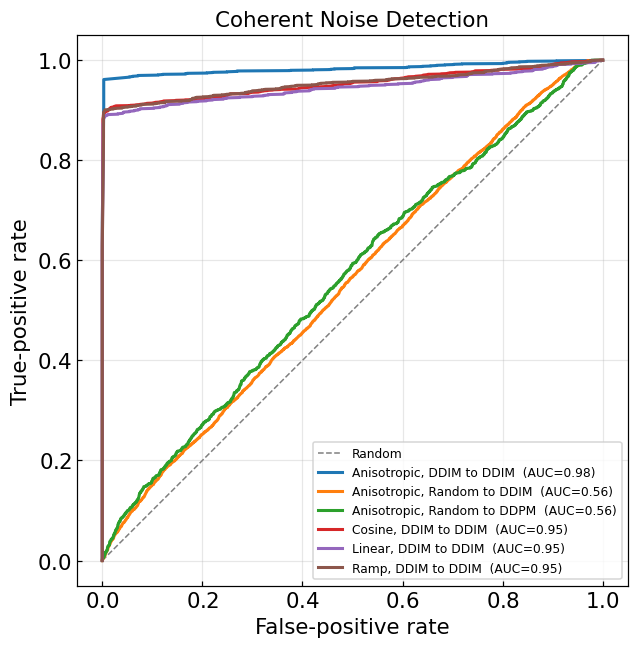

In [373]:
def smooth_roc(fpr: np.ndarray, tpr: np.ndarray, sigma: float) -> tuple[np.ndarray, np.ndarray]:
    """Apply Gaussian smoothing to a ROC curve, clamping TPR to [0, 1] and
    enforcing the (0,0) and (1,1) boundary points afterward."""
    if sigma <= 0:
        return fpr, tpr
    tpr_smooth = gaussian_filter1d(tpr, sigma=sigma)
    tpr_smooth = np.clip(tpr_smooth, 0.0, 1.0)
    # Restore exact boundary values so the curve still touches the corners.
    tpr_smooth[0]  = tpr[0]
    tpr_smooth[-1] = tpr[-1]
    return fpr, tpr_smooth


if not records:
    print("No ROC curves to plot. Check ROC_DIR or ROC_FILES.")
else:
    fig, ax = plt.subplots(figsize=FIG_SIZE)

    if SHOW_DIAGONAL:
        ax.plot([0, 1], [0, 1], linestyle="--", color="grey", lw=1, label="Random")

    for rec, label in zip(records, labels):
        fpr = np.asarray(rec["fpr"])
        tpr = np.asarray(rec["tpr"])
        if "rand2ddim" in rec["label"]:
            fpr, tpr = smooth_roc(fpr, tpr, 20)
        else:
            fpr, tpr = smooth_roc(fpr, tpr, 1)
        auc_val = rec.get("auc", float("nan"))
        ax.plot(
            fpr, tpr,
            lw=2,
            label=f"{label}  (AUC={auc_val:.2f})",
        )

    ax.set_xlabel("False-positive rate")
    ax.set_ylabel("True-positive rate")
    ax.set_title("Coherent Noise Detection")
    # ax.set_xlim(0, 1)
    # ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="lower right", fontsize=8)
    if SHOW_GRID:
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"figures_paper/ROC-{DEFECT_TYPE}-morestat.pdf", bbox_inches="tight")
    plt.show()


In [361]:
!cp figures_paper/ROC* /exp/sbnd/app/users/munjung/anomaly-detection/figures_paper/.

In [354]:
# Print a summary table sorted by AUC (descending).
if records:
    sorted_recs = sorted(records, key=lambda r: r.get("auc", 0), reverse=True)
    header = f"{'Label':<40} {'T':>5} {'Score':<14} {'n_nom':>7} {'n_def':>7} {'AUC':>8}"
    print(header)
    print("-" * len(header))
    for rec in sorted_recs:
        print(
            f"{rec.get('label', '?'):<40}"
            f" {str(rec.get('T', '?')):>5}"
            f" {rec.get('score_mode', '?'):<14}"
            f" {rec.get('n_nominal_patches', '?'):>7}"
            f" {rec.get('n_defect_patches', '?'):>7}"
            f" {rec.get('auc', float('nan')):>8.4f}"
        )


Label                                        T Score            n_nom   n_def      AUC
--------------------------------------------------------------------------------------
ICARUS_plane1_coh_noise-anisotropic        200 rms                900    1980   0.9566
ICARUS_plane1_coh_noise                    200 rms               1415    3980   0.8789
ICARUS_plane1_coh_noise-cosine             200 rms                942    1980   0.8751
ICARUS_plane1_coh_noise-ramp               200 rms               2067    1980   0.8530
ICARUS_plane1_coh_noise-anisotropic        200 rms               6480    2980   0.5207
ICARUS_plane1_coh_noise-anisotropic        200 rms               6480    7760   0.5034
